<a href="https://colab.research.google.com/github/RoyalMaddy08/DARA_RSNN/blob/main/DARA_RSNN_VIT_SOC_Estimation_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DARA-RSNN -- Battery SOC Estimation from Voltage / Current / Temperature

Self-contained deployment demo for DARA-RSNN, kept separate from the research
notebook (trained/validated on the Panasonic 18650PF dataset).

**Input assumption for this notebook:** your CSV has only

    Time_s   Voltage_V   Current_A   Temp_C

There is no `SOC_%` column supplied. So the pipeline does two distinct things,
and it's important to keep them conceptually separate:

1. **Compute** a reference SOC via Coulomb counting (integrating `Current_A`
   over `Time_s`, referenced to a nominal capacity). This is *not* the model's
   prediction -- it's just how we generate a training label, the same way the
   research notebook used the Panasonic dataset's provided SOC.
2. **Estimate** SOC using DARA-RSNN from `Voltage_V`, `Current_A`, `Temp_C`
   alone. This is the actual model output. It matters that the model doesn't
   simply re-derive Coulomb counting internally -- Coulomb counting drifts
   over long horizons (sensor bias, unknown true starting SOC, capacity fade),
   so a model that also leverages voltage/temperature relationships can be
   more robust in deployment than integration alone.

**Reservoir fix retained from before:** spectral radius normalized to <1
(echo-state property) with leaky integration, instead of the original raw
random matrix (spectral radius ~11, unstable).

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import random
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Config

Only these values should need to change when the dataset changes.

- `Q_NOMINAL_AH` -- the cell's nominal capacity, used to convert integrated
  current into a SOC percentage. Get this from the cell's datasheet.
- `INITIAL_SOC_PERCENT` -- SOC assumed at the very first row of the file.
  100.0 is correct if logging starts from a full charge; set it lower if not.
- `CURRENT_SIGN_CONVENTION` -- set to `"discharge_positive"` if positive
  current in your file means the battery is discharging (draining), or
  `"charge_positive"` if positive current means charging. Get this wrong and
  the computed SOC curve will run backwards -- always sanity-check the plot
  in Section 4 before trusting it.

In [4]:
# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "/content/battery_log_vit_only.csv"

TIME_COLUMN = "Time_s"
VOLTAGE_COLUMN = "Voltage_V"
CURRENT_COLUMN = "Current_A"
TEMP_COLUMN = "Temp_C"

TARGET_COLUMN = "SOC_%"              # computed in Section 4, not present in the raw file
Q_NOMINAL_AH = 3.0                   # nominal cell capacity (Ah) -- set from datasheet
INITIAL_SOC_PERCENT = 100.0          # assumed SOC at the first row of the file
CURRENT_SIGN_CONVENTION = "discharge_positive"   # or "charge_positive"

ADD_POWER_FEATURE = True             # engineer Power_W = V * I as an extra input feature

SEQ_LENGTH = 20                      # sliding window length (tune per sampling rate)

## 3. Load Raw Data

In [5]:
df = pd.read_csv(CSV_PATH)

required = [TIME_COLUMN, VOLTAGE_COLUMN, CURRENT_COLUMN, TEMP_COLUMN]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing expected columns: {missing}. Found: {df.columns.tolist()}"

before = len(df)
df = df.dropna(subset=required).reset_index(drop=True)
dropped = before - len(df)
if dropped > 0:
    print(f"Dropped {dropped} rows containing NaNs in required columns")

df = df.sort_values(TIME_COLUMN).reset_index(drop=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (5760, 4)
Columns: ['Time_s', 'Voltage_V', 'Current_A', 'Temp_C']


,Time_s,Voltage_V,Current_A,Temp_C
0,0.0,4.1205,1.8000,26.007
1,1.0,4.1152,1.7975,26.004
2,2.0,4.1136,1.7961,25.993
3,3.0,4.1203,1.8031,26.002
4,4.0,4.1124,1.7972,25.996


## 4. Compute SOC via Coulomb Counting

This produces the training **label**. It integrates current over time:

    SOC[t+dt] = SOC[t] - (I * dt) / (3600 * Q_nominal) * 100

**This is not the model's prediction** -- it's a reference signal derived
purely from the current sensor, used the same way ground-truth SOC was used
from the Panasonic dataset. The model in Section 6 onward never sees this
formula; it only sees Voltage/Current/Temperature and learns to predict this
computed SOC from those.

Check the printed range and the plot below before proceeding -- if SOC runs
from low to high instead of high to low (or looks inverted/discontinuous),
flip `CURRENT_SIGN_CONVENTION` in the config cell above and re-run.

In [6]:
def compute_soc_coulomb_counting(time_s, current_a, q_nominal_ah,
                                  initial_soc=100.0,
                                  sign_convention="discharge_positive"):
    t = np.asarray(time_s, dtype=float)
    I = np.asarray(current_a, dtype=float)

    if sign_convention == "charge_positive":
        I = -I   # flip so positive I always means discharge internally
    elif sign_convention != "discharge_positive":
        raise ValueError('CURRENT_SIGN_CONVENTION must be "discharge_positive" or "charge_positive"')

    dt = np.diff(t, prepend=t[0])
    dt[0] = 0.0

    delta_soc = -(I * dt) / (3600.0 * q_nominal_ah) * 100.0
    soc = initial_soc + np.cumsum(delta_soc)

    return np.clip(soc, 0.0, 100.0)


df[TARGET_COLUMN] = compute_soc_coulomb_counting(
    df[TIME_COLUMN],
    df[CURRENT_COLUMN],
    q_nominal_ah=Q_NOMINAL_AH,
    initial_soc=INITIAL_SOC_PERCENT,
    sign_convention=CURRENT_SIGN_CONVENTION,
)

print(f"Computed {TARGET_COLUMN} range:", df[TARGET_COLUMN].min(), "to", df[TARGET_COLUMN].max())

Computed SOC_% range: 47.82891759259241 to 100.0


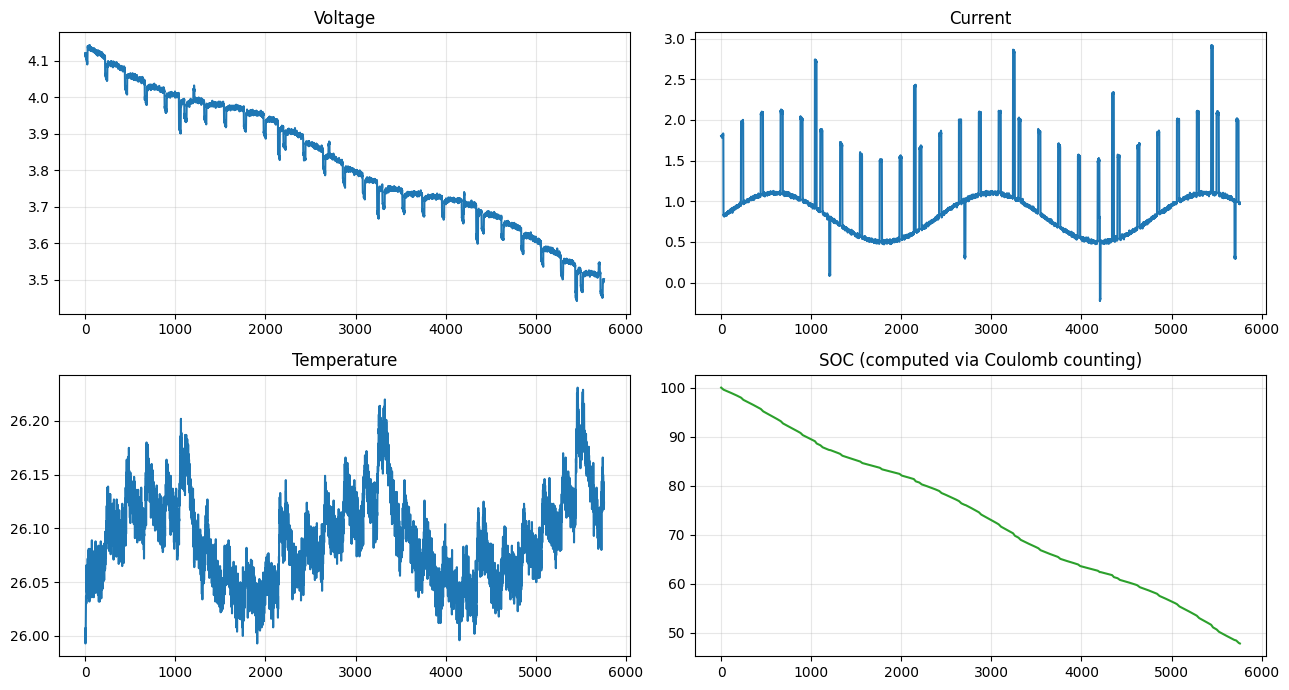

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7))

ax[0,0].plot(df[TIME_COLUMN], df[VOLTAGE_COLUMN]); ax[0,0].set_title("Voltage")
ax[0,1].plot(df[TIME_COLUMN], df[CURRENT_COLUMN]); ax[0,1].set_title("Current")
ax[1,0].plot(df[TIME_COLUMN], df[TEMP_COLUMN]);    ax[1,0].set_title("Temperature")
ax[1,1].plot(df[TIME_COLUMN], df[TARGET_COLUMN], color="tab:green")
ax[1,1].set_title("SOC (computed via Coulomb counting)")

for a in ax.flat:
    a.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Demo_Signals_Overview.png", dpi=600, bbox_inches="tight")
plt.show()

## 5. Feature Selection

The model estimates SOC from `Voltage_V`, `Current_A`, `Temp_C` only (plus an
optional engineered `Power_W` term). It deliberately does **not** get access
to the running Coulomb-count itself as an input -- only the label was derived
from it. If we fed the running integral in as a feature too, the model could
trivially learn to copy it rather than learning a genuine V/I/T -> SOC
relationship.

In [8]:
if ADD_POWER_FEATURE:
    df["Power_W"] = df[VOLTAGE_COLUMN] * df[CURRENT_COLUMN]
    FEATURES = [VOLTAGE_COLUMN, CURRENT_COLUMN, TEMP_COLUMN, "Power_W"]
else:
    FEATURES = [VOLTAGE_COLUMN, CURRENT_COLUMN, TEMP_COLUMN]

TARGET = TARGET_COLUMN

print("Features (%d):" % len(FEATURES), FEATURES)
print("Target:", TARGET)

Features (4): ['Voltage_V', 'Current_A', 'Temp_C', 'Power_W']
Target: SOC_%


## 6. Preprocessing

Scale -> sequence -> **randomized** train/val/test split (a chronological split previously caused a train/test SOC-range mismatch and model output collapse).

In [9]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X = feature_scaler.fit_transform(df[FEATURES])
y = target_scaler.fit_transform(df[[TARGET]])   # keep 2D: shape (N,1)

print("X:", X.shape, " y:", y.shape)

X: (5760, 4)  y: (5760, 1)


In [10]:
X_seq, y_seq = [], []
for i in range(len(X) - SEQ_LENGTH):
    X_seq.append(X[i:i+SEQ_LENGTH])
    y_seq.append(y[i+SEQ_LENGTH])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)   # shape (N, 1)

print("X_seq:", X_seq.shape, " y_seq:", y_seq.shape)

X_seq: (5740, 20, 4)  y_seq: (5740, 1)


In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.30, random_state=SEED, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, shuffle=True
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train SOC range:", y_train.min(), y_train.max())
print("Val   SOC range:", y_val.min(), y_val.max())
print("Test  SOC range:", y_test.min(), y_test.max())

Train: (4018, 20, 4)  Val: (861, 20, 4)  Test: (861, 20, 4)
Train SOC range: 0.0 0.9936055998383806
Val   SOC range: 0.0005236155995246294 0.9911430642301506
Test  SOC range: 0.0006946341371993903 0.9917305189413412


In [12]:
batch_size = 64

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
    batch_size=batch_size, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
    batch_size=batch_size, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)),
    batch_size=batch_size, shuffle=False
)

print(len(train_loader), len(val_loader), len(test_loader))

63 14 14


## 7. DARA-RSNN Model

Spike Encoder -> Reservoir (spectral-radius fixed, input size auto-set from `len(FEATURES)`) -> Dual Adaptive Reservoir Attention -> Readout.

In [13]:
# ============================================================
# Spike Encoder -- stochastic (Bernoulli) rate encoding
#
# During TRAINING: samples a fresh random spike pattern each forward
# pass (E[Bernoulli(x)] = x). This is a legitimate regularizer.
#
# During EVAL: uses the expected spike rate (= x itself) instead of
# sampling. Without this, the identical input produces a different
# random spike pattern on every forward call, which injects
# irreducible noise into predictions at inference time and creates a
# hard floor on validation/test loss no matter how long you train.
# Same idea as disabling Dropout at test time.
# ============================================================
class SpikeEncoder(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # x : (batch, sequence, features), values in [0,1]
        if self.training:
            return (x > torch.rand_like(x)).float()
        else:
            return x

In [14]:
# ============================================================
# Reservoir Layer -- FIXED
# Raw random matrices have spectral radius ~sqrt(N) (~11 for N=128),
# which is unstable / chaotic. This normalizes spectral radius to
# <1 (echo-state property) and adds leaky integration.
# ============================================================
class Reservoir(nn.Module):

    def __init__(self, input_size, reservoir_size=128,
                 spectral_radius=0.9, leak_rate=0.3,
                 input_scale=0.5, seed=SEED):
        super().__init__()

        gen = np.random.default_rng(seed)

        W_in = gen.normal(0, 1, size=(input_size, reservoir_size)) * input_scale

        W = gen.normal(0, 1, size=(reservoir_size, reservoir_size))
        radius = np.max(np.abs(np.linalg.eigvals(W)))
        W = (W / radius) * spectral_radius

        self.W_in = nn.Parameter(torch.tensor(W_in, dtype=torch.float32), requires_grad=False)
        self.W = nn.Parameter(torch.tensor(W, dtype=torch.float32), requires_grad=False)
        self.leak_rate = leak_rate

    def forward(self, spikes):
        batch, seq, _ = spikes.shape
        state = torch.zeros(batch, self.W.shape[0], device=spikes.device)
        outputs = []

        for t in range(seq):
            candidate = torch.tanh(spikes[:, t] @ self.W_in + state @ self.W)
            state = (1 - self.leak_rate) * state + self.leak_rate * candidate
            outputs.append(state)

        return torch.stack(outputs, dim=1)

In [15]:
# ============================================================
# Dual Adaptive Reservoir Attention (DARA)
# ============================================================
class DARA(nn.Module):

    def __init__(self, reservoir_size=128):
        super().__init__()

        self.temporal = nn.Sequential(
            nn.Linear(reservoir_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.neuron = nn.Sequential(
            nn.Linear(reservoir_size, reservoir_size),
            nn.Sigmoid()
        )

    def forward(self, reservoir):
        # reservoir : (batch, seq, reservoir_size)
        temporal_scores = self.temporal(reservoir)
        temporal_weights = torch.softmax(temporal_scores, dim=1)
        temporal_context = (temporal_weights * reservoir).sum(dim=1)

        neuron_weights = self.neuron(temporal_context)
        context = temporal_context * neuron_weights

        return context

In [16]:
# ============================================================
# Readout
# ============================================================
class Readout(nn.Module):

    def __init__(self, reservoir_size=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(reservoir_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.fc(x)

In [17]:
# ============================================================
# Full DARA-RSNN
# ============================================================
class DARA_RSNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()
        self.encoder = SpikeEncoder()
        self.reservoir = Reservoir(input_size=input_size, spectral_radius=0.9, leak_rate=0.3)
        self.dara = DARA()
        self.readout = Readout()

    def forward(self, x):
        spikes = self.encoder(x)
        reservoir = self.reservoir(spikes)
        context = self.dara(reservoir)
        output = self.readout(context)
        return output

model = DARA_RSNN(input_size=len(FEATURES)).to(device)
print(model)

DARA_RSNN(
  (encoder): SpikeEncoder()
  (reservoir): Reservoir()
  (dara): DARA(
    (temporal): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
    (neuron): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Sigmoid()
    )
  )
  (readout): Readout(
    (fc): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=64, out_features=32, bias=True)
      (4): ReLU()
      (5): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


### 7a. Sanity check -- confirm the reservoir isn't collapsing

Verify two different input samples produce meaningfully different reservoir states before spending time training.

In [18]:
X_batch, _ = next(iter(test_loader))
X_batch = X_batch.to(device)

with torch.no_grad():
    spikes = model.encoder(X_batch)
    res_out = model.reservoir(spikes)

print("Reservoir output  min/max/mean:",
      res_out.min().item(), res_out.max().item(), res_out.mean().item())

diff = (res_out[0, -1] - res_out[1, -1]).abs().mean().item()
print("Mean abs difference between two different samples' final states:", diff)
print("(should be clearly non-trivial, e.g. > 0.05 -- if near 0, reservoir is still collapsing)")

Reservoir output  min/max/mean: -0.9583449363708496 0.9865845441818237 -0.03401488438248634
Mean abs difference between two different samples' final states: 0.19653773307800293
(should be clearly non-trivial, e.g. > 0.05 -- if near 0, reservoir is still collapsing)


### 7b. Determinism check -- confirm eval-mode predictions are stable

Runs the exact same input window through the model twice in eval mode. Before
the encoder fix, these would differ (stochastic spike resampling every call).
After the fix, they should be identical.

In [19]:
model.eval()

with torch.no_grad():
    pred_a = model(X_batch)
    pred_b = model(X_batch)

max_diff = (pred_a - pred_b).abs().max().item()
print("Max difference between two eval-mode passes on the same input:", max_diff)
print("(should be exactly 0.0 now -- if not, the encoder is still sampling at eval time)")

Max difference between two eval-mode passes on the same input: 0.0
(should be exactly 0.0 now -- if not, the encoder is still sampling at eval time)


## 8. Training

In [20]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=8)

EPOCHS = 120
best_val_loss = float("inf")
train_history, val_history = [], []

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            val_running_loss += criterion(pred, y_batch).item()
    val_loss = val_running_loss / len(val_loader)

    scheduler.step(val_loss)
    train_history.append(train_loss)
    val_history.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "dara_rsnn_best.pt")

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train {train_loss:.6f} | Val {val_loss:.6f} "
              f"| LR {optimizer.param_groups[0]['lr']:.2e}")

print("\nBest val loss:", best_val_loss)
model.load_state_dict(torch.load("dara_rsnn_best.pt"))

print("\nNote: train loss > val loss is expected here -- train mode still samples")
print("stochastic spikes (adds noise to the reported loss), eval mode doesn't.")

Epoch 001/120 | Train 0.058883 | Val 0.010987 | LR 1.00e-03
Epoch 010/120 | Train 0.011627 | Val 0.005481 | LR 1.00e-03
Epoch 020/120 | Train 0.011303 | Val 0.003688 | LR 1.00e-03
Epoch 030/120 | Train 0.010962 | Val 0.002932 | LR 1.00e-03
Epoch 040/120 | Train 0.009649 | Val 0.002858 | LR 5.00e-04
Epoch 050/120 | Train 0.010033 | Val 0.001643 | LR 2.50e-04
Epoch 060/120 | Train 0.010061 | Val 0.002128 | LR 1.25e-04
Epoch 070/120 | Train 0.009800 | Val 0.001845 | LR 6.25e-05
Epoch 080/120 | Train 0.009754 | Val 0.001999 | LR 6.25e-05
Epoch 090/120 | Train 0.009921 | Val 0.001701 | LR 3.13e-05
Epoch 100/120 | Train 0.009691 | Val 0.001731 | LR 1.56e-05
Epoch 110/120 | Train 0.009810 | Val 0.001840 | LR 7.81e-06
Epoch 120/120 | Train 0.009713 | Val 0.001780 | LR 3.91e-06

Best val loss: 0.001453754142858088

Note: train loss > val loss is expected here -- train mode still samples
stochastic spikes (adds noise to the reported loss), eval mode doesn't.


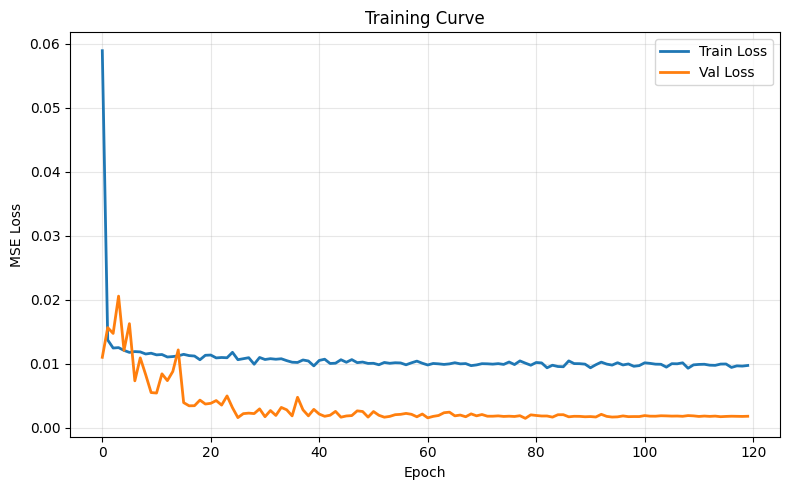

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="Train Loss", linewidth=2)
plt.plot(val_history, label="Val Loss", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Demo_Training_Curve.png", dpi=600, bbox_inches="tight")
plt.show()

## 9. Evaluation

Compares the model's V/I/T-based SOC **estimate** against the Coulomb-counted **reference** SOC on held-out sequences.

In [22]:
model.eval()
predictions, targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        predictions.append(output.cpu().numpy())
        targets.append(y_batch.numpy())

predictions = np.vstack(predictions)
targets = np.vstack(targets)

predictions = target_scaler.inverse_transform(predictions)
targets = target_scaler.inverse_transform(targets)

rmse = np.sqrt(mean_squared_error(targets, predictions))
mae = mean_absolute_error(targets, predictions)
mape = np.mean(np.abs((targets - predictions) / (targets + 1e-8))) * 100
r2 = r2_score(targets, predictions)

print("="*45)
print("DARA-RSNN SOC Estimation Performance")
print("(vs. Coulomb-counted reference SOC)")
print("="*45)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

DARA-RSNN SOC Estimation Performance
(vs. Coulomb-counted reference SOC)
RMSE : 2.0406
MAE  : 1.7630
MAPE : 2.59%
R2   : 0.9809


### 9a. Bias check -- error by SOC range

If the model systematically under- or over-estimates in specific SOC bands
(e.g. consistently low near full charge), it'll show up here as a nonzero
mean bias in that row, even if overall RMSE/R2 look good. A well-calibrated
model should show mean bias close to 0 in every band.

In [23]:
residual = (predictions - targets).flatten()
true_soc = targets.flatten()

bins = [(0,50),(50,60),(60,70),(70,80),(80,90),(90,95),(95,100.001)]
print(f"{'SOC range':>12} {'n':>6} {'mean bias':>10} {'MAE':>8}")
print("-" * 40)
for lo, hi in bins:
    mask = (true_soc >= lo) & (true_soc < hi)
    if mask.sum() == 0:
        continue
    mean_bias = residual[mask].mean()
    mae_bin = np.abs(residual[mask]).mean()
    print(f"[{lo:>4.0f},{hi:>5.0f}) {mask.sum():>6} {mean_bias:>+10.3f} {mae_bin:>8.3f}")

print("\n(mean bias = predicted - reference; negative = model underestimates in that range)")

   SOC range      n  mean bias      MAE
----------------------------------------
[   0,   50)     30     +2.729    2.729
[  50,   60)    150     +2.480    2.485
[  60,   70)    184     +2.260    2.260
[  70,   80)    138     +1.719    1.719
[  80,   90)    199     -0.202    0.448
[  90,   95)     72     -1.137    1.137
[  95,  100)     88     -2.719    2.719

(mean bias = predicted - reference; negative = model underestimates in that range)


### 9b. Post-hoc Bias Calibration

The bias pattern above (over-estimates low SOC, under-estimates high SOC,
roughly linear) is a classic **shrinkage-toward-the-mean** signature -- common
in regularized, limited-capacity regressors (a fixed random reservoir + small
trainable readout behaves similarly to ridge regression in this respect).
More training epochs won't fix this; it's a structural property of the
estimator, not an under-convergence issue.

Since the bias trend is close to linear in true SOC, a standard fix is a
**post-hoc linear recalibration**: fit `SOC_calibrated = a * SOC_raw_pred + b`
using the **validation set only** (never the test set), then apply it to
every prediction downstream -- including the live dashboard. This is cheap,
standard practice in deployed ML systems, and doesn't require retraining.

In [24]:
# Fit calibration on VALIDATION predictions only (test set stays untouched for honest evaluation)
model.eval()
val_preds, val_true = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        out = model(X_batch).cpu().numpy()
        val_preds.append(out)
        val_true.append(y_batch.numpy())

val_preds = target_scaler.inverse_transform(np.vstack(val_preds))
val_true = target_scaler.inverse_transform(np.vstack(val_true))

calibrator = LinearRegression()
calibrator.fit(val_preds, val_true)

a = calibrator.coef_[0][0]
b = calibrator.intercept_[0]
print(f"Calibration fit on validation set: SOC_calibrated = {a:.4f} * SOC_raw_pred + {b:.4f}")

Calibration fit on validation set: SOC_calibrated = 1.1152 * SOC_raw_pred + -9.6223


In [25]:
# Apply calibration to the (held-out, never-seen-by-calibrator) test predictions
predictions_calibrated = calibrator.predict(predictions)

rmse_c = np.sqrt(mean_squared_error(targets, predictions_calibrated))
mae_c = mean_absolute_error(targets, predictions_calibrated)
mape_c = np.mean(np.abs((targets - predictions_calibrated) / (targets + 1e-8))) * 100
r2_c = r2_score(targets, predictions_calibrated)

print("="*45)
print("AFTER calibration (test set)")
print("="*45)
print(f"RMSE : {rmse_c:.4f}  (was {rmse:.4f})")
print(f"MAE  : {mae_c:.4f}  (was {mae:.4f})")
print(f"MAPE : {mape_c:.2f}%  (was {mape:.2f}%)")
print(f"R2   : {r2_c:.4f}  (was {r2:.4f})")

print("\nBias by SOC range AFTER calibration:")
residual_c = (predictions_calibrated - targets).flatten()
print(f"{'SOC range':>12} {'n':>6} {'mean bias':>10} {'MAE':>8}")
print("-" * 40)
for lo, hi in bins:
    mask = (true_soc >= lo) & (true_soc < hi)
    if mask.sum() == 0:
        continue
    mean_bias = residual_c[mask].mean()
    mae_bin = np.abs(residual_c[mask]).mean()
    print(f"[{lo:>4.0f},{hi:>5.0f}) {mask.sum():>6} {mean_bias:>+10.3f} {mae_bin:>8.3f}")

AFTER calibration (test set)
RMSE : 0.9802  (was 2.0406)
MAE  : 0.7223  (was 1.7630)
MAPE : 1.02%  (was 2.59%)
R2   : 0.9956  (was 0.9809)

Bias by SOC range AFTER calibration:
   SOC range      n  mean bias      MAE
----------------------------------------
[   0,   50)     30     -0.938    1.315
[  50,   60)    150     -0.431    0.795
[  60,   70)    184     +0.331    0.549
[  70,   80)    138     +0.996    0.996
[  80,   90)    199     -0.088    0.409
[  90,   95)     72     -0.202    0.280
[  95,  100)     88     -1.398    1.398


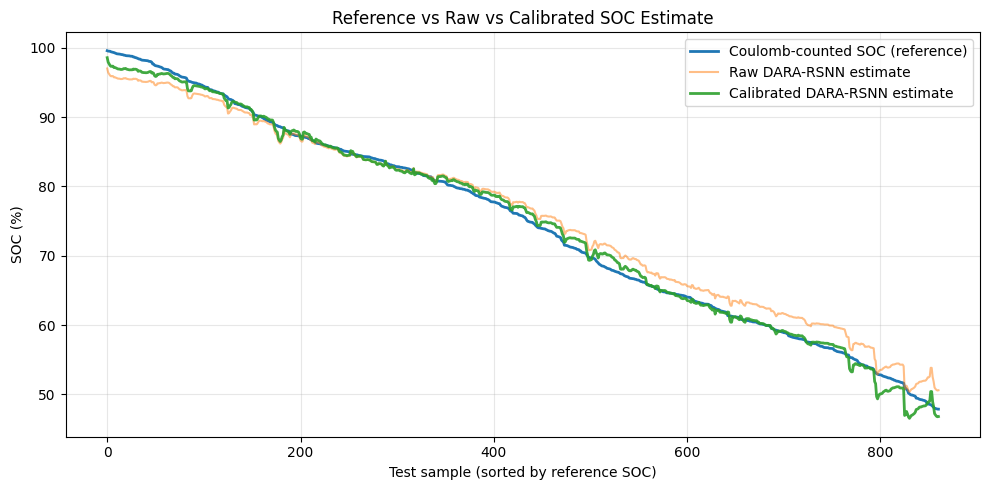

In [26]:
order = np.argsort(targets.flatten())[::-1]

plt.figure(figsize=(10, 5))
plt.plot(targets[order], label="Coulomb-counted SOC (reference)", linewidth=2)
plt.plot(predictions[order], label="Raw DARA-RSNN estimate", linewidth=1.5, alpha=0.5)
plt.plot(predictions_calibrated[order], label="Calibrated DARA-RSNN estimate", linewidth=2, alpha=0.9)
plt.xlabel("Test sample (sorted by reference SOC)")
plt.ylabel("SOC (%)")
plt.title("Reference vs Raw vs Calibrated SOC Estimate")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Demo_SOC_Estimation_Calibrated.png", dpi=600, bbox_inches="tight")
plt.show()

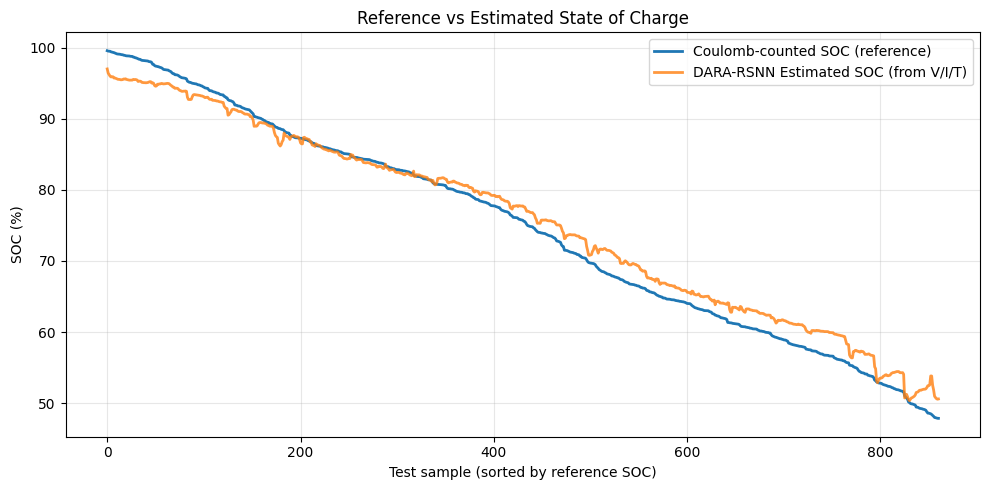

In [27]:
order = np.argsort(targets.flatten())[::-1]  # sort by reference SOC for a clean curve

plt.figure(figsize=(10, 5))
plt.plot(targets[order], label="Coulomb-counted SOC (reference)", linewidth=2)
plt.plot(predictions[order], label="DARA-RSNN Estimated SOC (from V/I/T)", linewidth=2, alpha=0.8)
plt.xlabel("Test sample (sorted by reference SOC)")
plt.ylabel("SOC (%)")
plt.title("Reference vs Estimated State of Charge")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Demo_SOC_Estimation.png", dpi=600, bbox_inches="tight")
plt.show()

## 10. Live Replay Dashboard

Streams the loaded V/I/T profile through the trained model one window at a time, mimicking a deployed Battery Management System (BMS) that estimates SOC without ever running its own Coulomb integration. Applies the Section 9b calibration so displayed values match the evaluated test metrics.

In [28]:
def health_status(soc):
    if soc >= 60:
        return "Healthy"
    elif soc >= 30:
        return "Aging / Monitor"
    else:
        return "Low Charge"

model.eval()
n_demo_steps = 15
start_idx = 100  # arbitrary starting point in the raw signal

print(f"{'Time(s)':>8} {'Volt(V)':>8} {'Curr(A)':>8} {'Temp(C)':>8} "
      f"{'Ref SOC':>9} {'Raw Est':>9} {'Calib Est':>10}  Status")
print("-" * 80)

with torch.no_grad():
    for step in range(n_demo_steps):
        i = start_idx + step

        window_raw = df[FEATURES].iloc[i : i + SEQ_LENGTH].values
        window_scaled = feature_scaler.transform(window_raw)
        window_tensor = torch.FloatTensor(window_scaled).unsqueeze(0).to(device)

        pred_scaled = model(window_tensor).cpu().numpy()
        raw_est_soc = target_scaler.inverse_transform(pred_scaled)[0, 0]
        calib_est_soc = calibrator.predict([[raw_est_soc]])[0, 0]

        ref_soc = df[TARGET].iloc[i + SEQ_LENGTH]
        t = df[TIME_COLUMN].iloc[i + SEQ_LENGTH]
        v = df[VOLTAGE_COLUMN].iloc[i + SEQ_LENGTH]
        c = df[CURRENT_COLUMN].iloc[i + SEQ_LENGTH]
        temp_c = df[TEMP_COLUMN].iloc[i + SEQ_LENGTH]

        print(f"{t:>8.0f} {v:>8.3f} {c:>8.3f} {temp_c:>8.2f} "
              f"{ref_soc:>9.2f} {raw_est_soc:>9.2f} {calib_est_soc:>10.2f}  {health_status(calib_est_soc)}")

 Time(s)  Volt(V)  Curr(A)  Temp(C)   Ref SOC   Raw Est  Calib Est  Status
--------------------------------------------------------------------------------
     120    4.128    0.887    26.04     98.84     95.49      96.87  Healthy
     121    4.125    0.892    26.07     98.83     95.46      96.84  Healthy
     122    4.129    0.891    26.07     98.82     95.43      96.81  Healthy
     123    4.117    0.895    26.08     98.81     95.42      96.79  Healthy
     124    4.118    0.887    26.07     98.81     95.43      96.80  Healthy
     125    4.124    0.857    26.05     98.80     95.44      96.81  Healthy
     126    4.124    0.913    26.07     98.79     95.43      96.80  Healthy
     127    4.121    0.884    26.05     98.78     95.44      96.81  Healthy
     128    4.124    0.912    26.05     98.77     95.43      96.81  Healthy
     129    4.124    0.900    26.05     98.76     95.44      96.81  Healthy
     130    4.126    0.901    26.07     98.76     95.43      96.81  Healthy
     131